In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from qseg import *
import cv2
from my_segmentation import *
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, recall_score, precision_score
import time
import copy
import pandas as pd
from itertools import product

In [2]:
# load new images
path = "datasets/spheroidite_particles/"
image_files = [f for f in os.listdir(path+"image_patches/")]
mask_files = [f for f in os.listdir(path+"label_patches/")]

images = [cv2.imread(path+"image_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in image_files]
masks = [cv2.imread(path+"label_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in mask_files]

In [3]:
# test run
i = 0
sample = sharpnening(images[i])
dim = sample.shape[0]

# image to graph
start = time.time()
G = qseg_graph_construction(sample, normalized=False)

bqm, sampleset = annealer_solver_sa(G)
sampleset_first = sampleset.first.sample
end = time.time()
runtime = round(end - start, 3)

accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
print(runtime, accuracy, iou, f1, precision, recall)


31.637 0.472 0.166 0.221 0.635 0.508


In [8]:
results = []

for i in range(len(images)):
    sample = sharpnening(images[i])
    dim = sample.shape[0]

    start = time.time()
    # image to graph
    G = qseg_graph_construction(sample, normalized=False)
    end = time.time()
    conversion_time = round(end-start,3)

    start = time.time()
    bqm, sampleset = annealer_solver_sa(G)
    sampleset_first = sampleset.first.sample
    end = time.time()
    annealing_time = round(end-start,3)

    accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
    
    results.append({
        'Accuracy': accuracy,
        'IoU': iou,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Conversion time': conversion_time,
        'Annealing time' : annealing_time,

    })

df = pd.DataFrame(results)
df

,Accuracy,IoU,Precision,Recall,F1,Conversion time,Annealing time
0,0.502,0.177,0.640,0.519,0.232,1.739,29.865
1,0.447,0.158,0.630,0.501,0.214,1.528,30.055
2,0.542,0.196,0.628,0.546,0.247,1.497,29.859
3,0.462,0.165,0.620,0.513,0.221,1.916,31.124
4,0.506,0.183,0.632,0.529,0.236,1.617,30.004
5,0.493,0.175,0.631,0.520,0.229,1.911,29.612
6,0.571,0.201,0.638,0.547,0.251,1.551,29.405
7,0.571,0.203,0.642,0.547,0.252,1.967,29.545
8,0.492,0.178,0.621,0.528,0.232,1.533,29.751
9,0.539,0.195,0.622,0.547,0.246,1.966,30.403


In [9]:
df.to_csv('spherodite_qseg.csv', index=False)

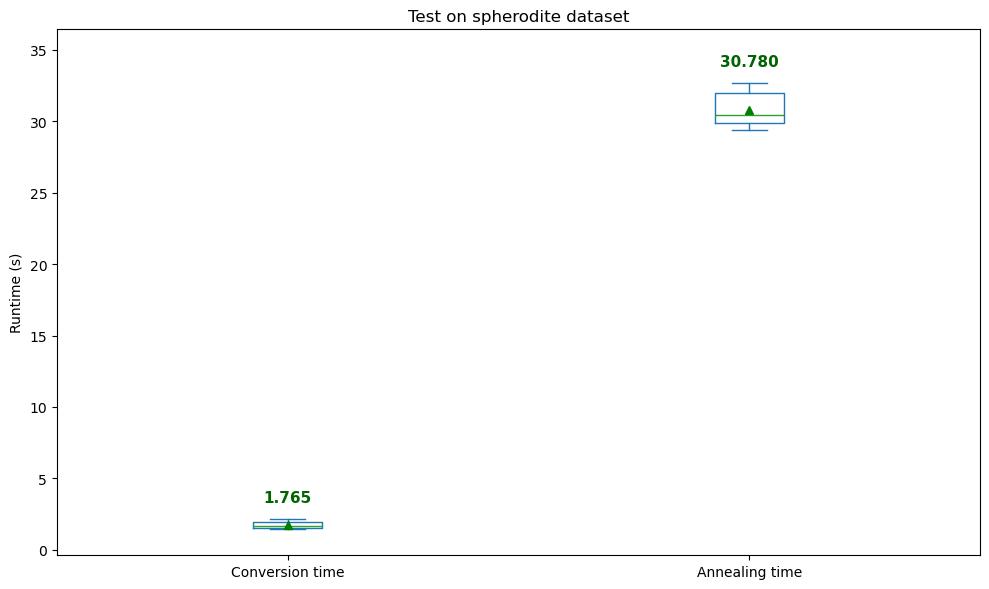

In [10]:
if 'idx' in df.columns:
    df = df.set_index('idx')

df_runtime = df[['Conversion time', 'Annealing time']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

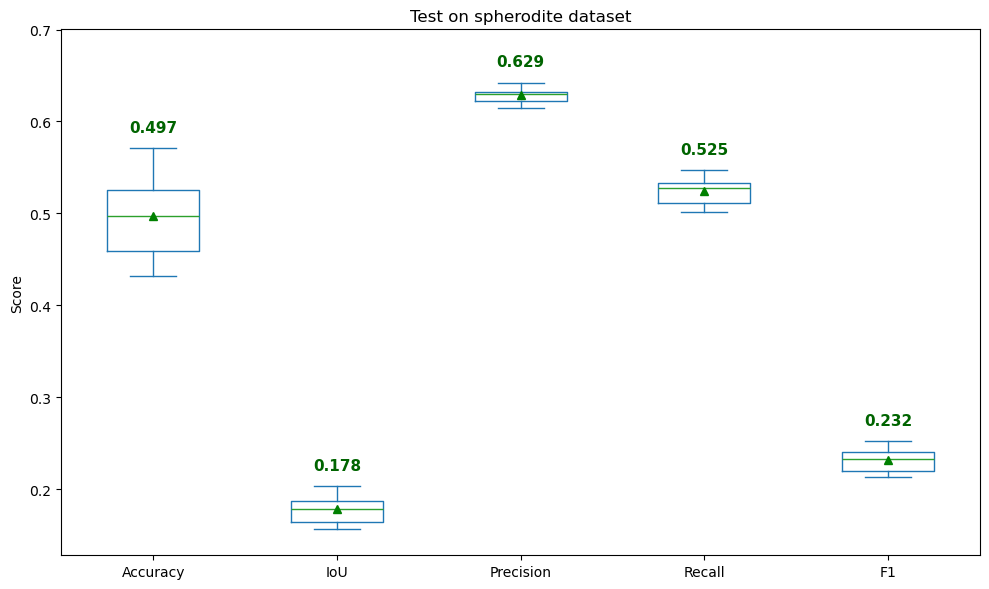

In [11]:
df.drop(columns=['Conversion time', 'Annealing time'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df.values.max() - df.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df.columns, start=1):
    mean_val = df[col].mean()
    max_val = df[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df.values.min() - y_offset * 2, df.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

Node sampling + Q-Seg

In [ ]:
# test run
i = 0
sample = sharpnening(images[i])
dim = sample.shape[0]

# image to graph
start = time.time()
G = qseg_graph_construction(sample, normalized=False)

bqm, sampleset = annealer_solver_sa(G)
sampleset_first = sampleset.first.sample
end = time.time()
runtime = round(end - start, 3)

accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
print(runtime, accuracy, iou, f1, precision, recall)

In [3]:
df_params = pd.read_csv('spherodite_this_work.csv')
l_th = df_params['thresholds'].tolist()
l_k = df_params['k'].tolist()

samplied_results = []

for i in range(len(images)):
    sample = sharpnening(images[i])
    dim = sample.shape[0]

    start = time.time()
    # image to graph
    G = qseg_graph_construction(sample, normalized=False)
    end = time.time()
    conversion_time = round(end-start,3)
    
    start = time.time()
    H, I, important, redundant = importance_sampling(G, threshold=l_th[i], node_size=0.1, show_graph=False)
    sampled_nodes = random_sampling(I, copy.deepcopy(redundant), k=l_k[i], seed=0)
    I.add_nodes_from(sampled_nodes)
    I = update_edgeweights_qseg(I, sample)
    end = time.time()
    sampling_time = round(end-start,3)
    
    start = time.time()
    bqm, sampleset = annealer_solver_sa(I)
    sampleset_first = sampleset.first.sample
    end = time.time()
    annealing_time = round(end-start,3)
    
    start = time.time()
    metrics_df = label_propagation_graph(I, sampleset_first, dim, masks[i])
    end = time.time()
    labeling_time = round(end-start,3)
    
    samplied_results.append({
        'Accuracy': metrics_df['accuracy'].iloc[0],
        'IoU': metrics_df['iou'].iloc[0],
        'Precision': metrics_df['precision'].iloc[0],
        'Recall': metrics_df['recall'].iloc[0],
        'F1': metrics_df['f1'].iloc[0],
        'Conversion time': conversion_time,
        'Sampling time' : sampling_time,
        'Annealing time' : annealing_time,
        'Labeling time' : labeling_time
    })
        
    df_results = pd.DataFrame(samplied_results)
    best_config = df_results.sort_values(by='IoU', ascending=False).iloc[0]

df_sampled = pd.DataFrame(samplied_results)
df_sampled

,Accuracy,IoU,Precision,Recall,F1,Conversion time,Sampling time,Annealing time,Labeling time
0,0.823,0.500,0.592,0.636,0.605,1.510,0.466,9.141,2.536
1,0.787,0.474,0.575,0.613,0.583,1.661,0.425,10.661,2.677
2,0.774,0.478,0.590,0.606,0.596,1.740,0.419,11.304,3.149
3,0.745,0.450,0.562,0.587,0.567,1.589,0.455,13.467,2.945
4,0.787,0.487,0.594,0.620,0.603,1.595,0.433,11.310,3.315
5,0.822,0.497,0.595,0.608,0.601,1.759,0.413,8.473,3.089
6,0.852,0.523,0.623,0.627,0.625,1.573,0.386,5.676,3.048
7,0.828,0.499,0.593,0.615,0.601,1.592,0.412,7.875,3.208
8,0.795,0.496,0.614,0.611,0.613,1.696,0.419,9.945,3.133
9,0.773,0.471,0.583,0.587,0.585,1.592,0.395,10.843,2.711


In [4]:
df_sampled.to_csv('spherodite_qseg_sampled.csv', index=False)

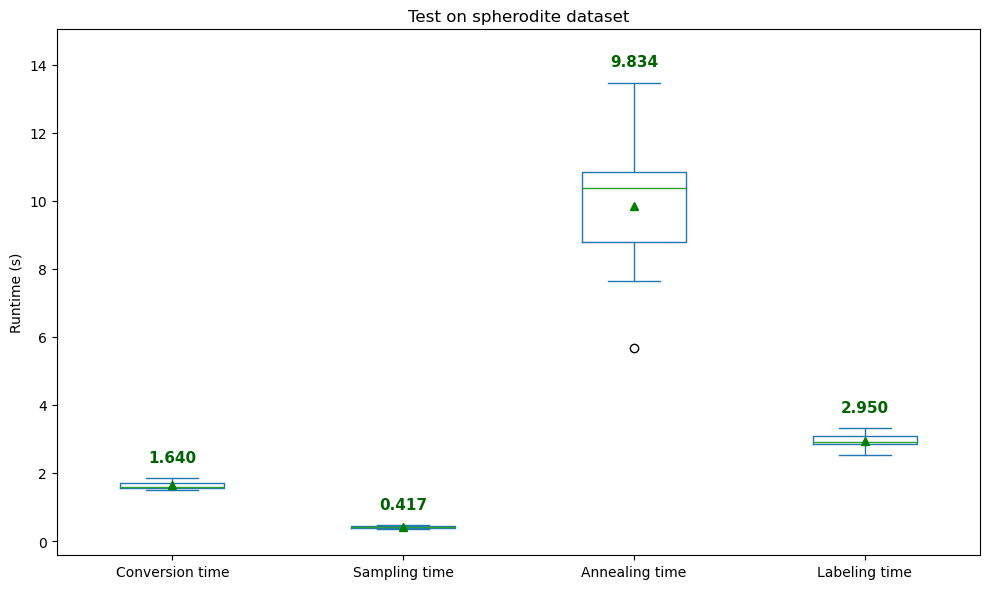

In [5]:
if 'idx' in df_sampled.columns:
    df_runtime = df_sampled.set_index('idx')

df_runtime = df_sampled[['Conversion time', 'Sampling time', 'Annealing time', 'Labeling time']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

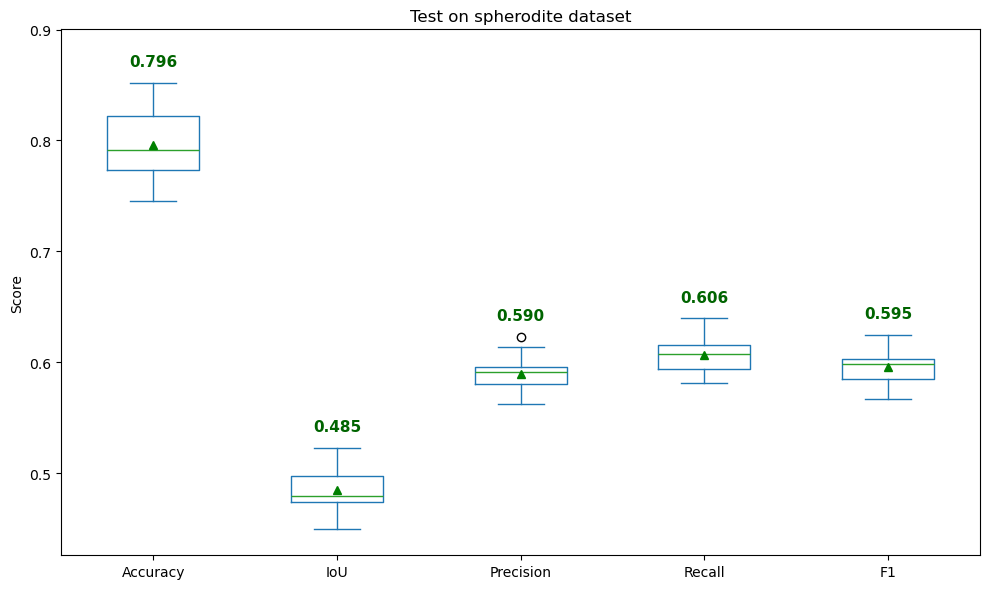

In [7]:
df_sampled.drop(columns=['Conversion time', 'Sampling time', 'Annealing time', 'Labeling time'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df_sampled.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_sampled.values.max() - df_sampled.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_sampled.columns, start=1):
    mean_val = df_sampled[col].mean()
    max_val = df_sampled[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_sampled.values.min() - y_offset * 2, df_sampled.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()